## What is Data Analysis
> process of inspecting, cleansing, transforming, and modeling data to discover useful information, informing concluding and supporting decision-making

In [737]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
%matplotlib inline

In [738]:
!/kaggle/input/sales-dataset-of-supermarket/sales.csv

/bin/bash: line 1: /kaggle/input/sales-dataset-of-supermarket/sales.csv: Permission denied


In [739]:
sales = pd.read_csv('/kaggle/input/sales-dataset-of-supermarket/sales.csv',parse_dates = ['Date'])

In [740]:
sales.head()

,Invoice ID,Date,Time,Gender,Location,City,Member,Category,Price,Quantity,Total,Payment,Rating
0,460489604,2018-01-25,16:46,Male,Brookfield,NewYork,Yes,Groceries,30,1,30,Cash,2
1,471006167,2018-03-19,16:48,Female,Water tower,Chicago,Yes,Fashion,35,5,175,Card,3
2,411909258,2018-02-25,13:33,Male,Water tower,Chicago,No,Clothing,57,2,114,Cash,5
3,487313402,2018-01-22,13:38,Female,Park lane,Dallas,Yes,Sporting,89,4,356,Gpay,1
4,197763430,2018-02-18,15:31,Female,Park lane,Dallas,No,Books,82,5,410,Cash,4


In [741]:
sales.shape

(1000, 13)

In [742]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Invoice ID  1000 non-null   int64         
 1   Date        1000 non-null   datetime64[ns]
 2   Time        1000 non-null   object        
 3   Gender      1000 non-null   object        
 4   Location    1000 non-null   object        
 5   City        1000 non-null   object        
 6   Member      1000 non-null   object        
 7   Category    1000 non-null   object        
 8   Price       1000 non-null   int64         
 9   Quantity    1000 non-null   int64         
 10  Total       1000 non-null   int64         
 11  Payment     1000 non-null   object        
 12  Rating      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(7)
memory usage: 101.7+ KB


In [743]:
sales.describe()

,Invoice ID,Date,Price,Quantity,Total,Rating
count,1.000000e+03,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.944931e+08,2018-02-14 00:05:45.600000,51.112000,4.059000,207.788000,2.972000
min,6.614050e+05,2018-01-01 00:00:00,1.000000,1.000000,1.000000,1.000000
25%,2.508726e+08,2018-01-24 00:00:00,27.000000,2.000000,72.000000,2.000000
50%,4.781491e+08,2018-02-13 00:00:00,51.000000,4.000000,174.000000,3.000000
75%,7.459453e+08,2018-03-08 00:00:00,76.250000,6.000000,304.500000,4.000000
max,9.996658e+08,2018-03-30 00:00:00,100.000000,7.000000,693.000000,5.000000
std,2.870685e+08,NaN,28.912443,2.027716,165.626167,1.428025


# Numerical analysis and visualization 

In [744]:
sales['Price'].describe()

count    1000.000000
mean       51.112000
std        28.912443
min         1.000000
25%        27.000000
50%        51.000000
75%        76.250000
max       100.000000
Name: Price, dtype: float64

In [745]:
sales['Total'].mean()

np.float64(207.788)

In [746]:
sales['Total'].median()

174.0

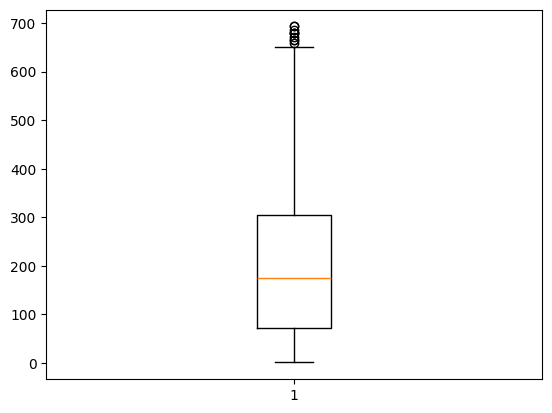

In [747]:
plt.boxplot( sales['Total'])
plt.show()

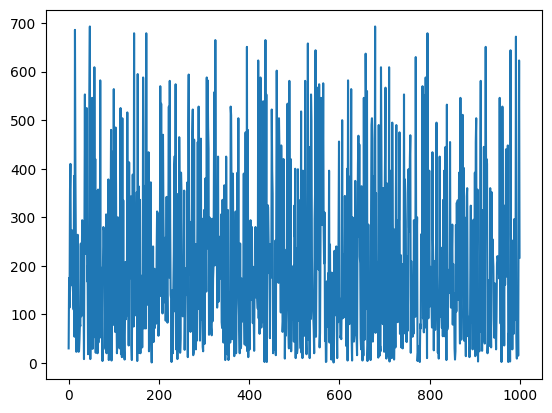

In [748]:
plt.plot(sales['Total'])

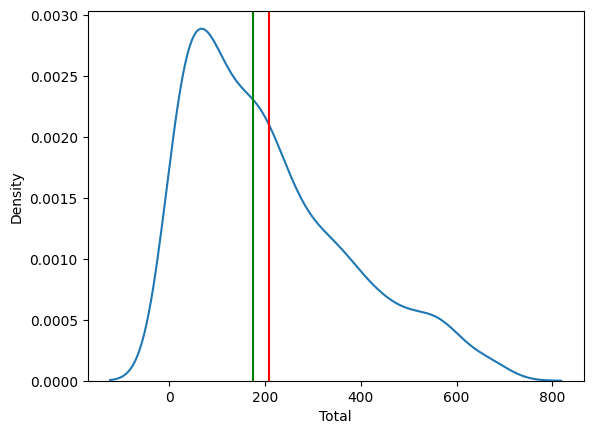

In [749]:
ax  =sns.distplot(sales['Total'], hist  = False)
#ax = sales['Price'].plot(kind = 'density',figsize = (14,6))
ax.axvline(sales['Total'].mean(),color = 'red')
ax.axvline(sales['Total'].median(),color = 'green')
plt.show()


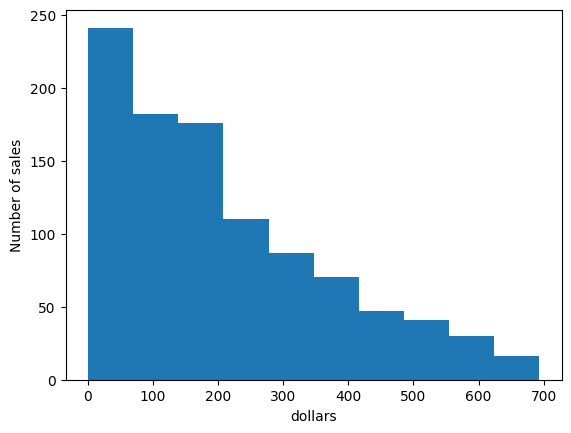

In [750]:
plt.hist(sales['Total'])
plt.ylabel('Number of sales')
plt.xlabel('dollars')
plt.show()

## Categorical analysis and visualization 

In [751]:
g =sales['Gender'].value_counts()
g

Gender
Female    501
Male      499
Name: count, dtype: int64

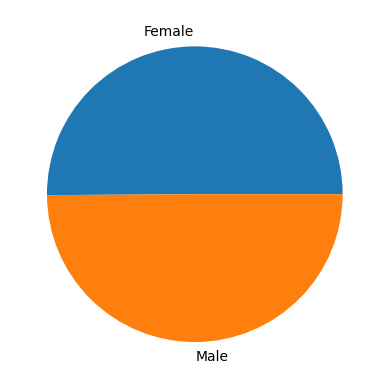

In [752]:
# fig , ax = plt.subplots()
plt.pie(g,labels = ['Female','Male'])
plt.show()

## Relationship between the columns?

In [753]:
sales.head(2)

,Invoice ID,Date,Time,Gender,Location,City,Member,Category,Price,Quantity,Total,Payment,Rating
0,460489604,2018-01-25,16:46,Male,Brookfield,NewYork,Yes,Groceries,30,1,30,Cash,2
1,471006167,2018-03-19,16:48,Female,Water tower,Chicago,Yes,Fashion,35,5,175,Card,3


In [754]:
new_sales  =sales[['Invoice ID',	'Date'	,'Price'	,'Quantity',	'Total'	,'Rating']]
corr = new_sales.corr()
corr

,Invoice ID,Date,Price,Quantity,Total,Rating
Invoice ID,1.000000,0.000511,-0.023990,-0.000928,-0.023896,-0.026243
Date,0.000511,1.000000,-0.012185,0.025502,0.007770,-0.001169
Price,-0.023990,-0.012185,1.000000,0.005539,0.696208,0.032176
Quantity,-0.000928,0.025502,0.005539,1.000000,0.626451,0.058302
Total,-0.023896,0.007770,0.696208,0.626451,1.000000,0.070696
Rating,-0.026243,-0.001169,0.032176,0.058302,0.070696,1.000000


<Figure size 800x800 with 0 Axes>

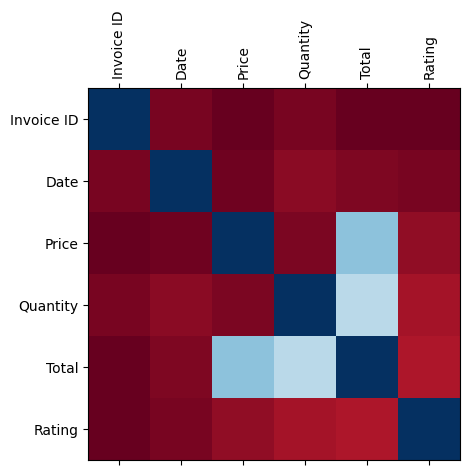

In [755]:
fig = plt.figure(figsize =(8,8))
plt.matshow(corr,cmap  = 'RdBu')
plt.xticks(range(len(corr.columns)),corr.columns  , rotation = 'vertical');
plt.yticks(range(len(corr.columns)),corr.columns);
plt.show()

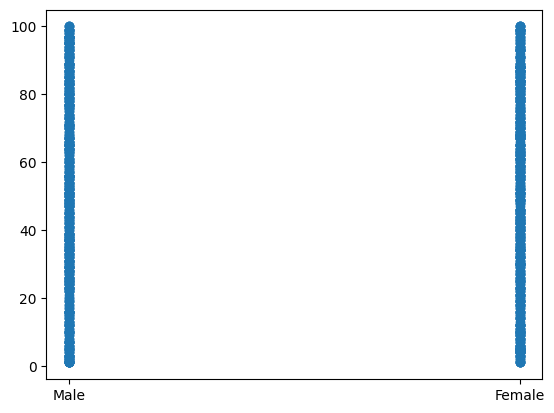

In [756]:
plt.scatter(data = sales ,x = 'Gender', y = 'Price')
plt.show()

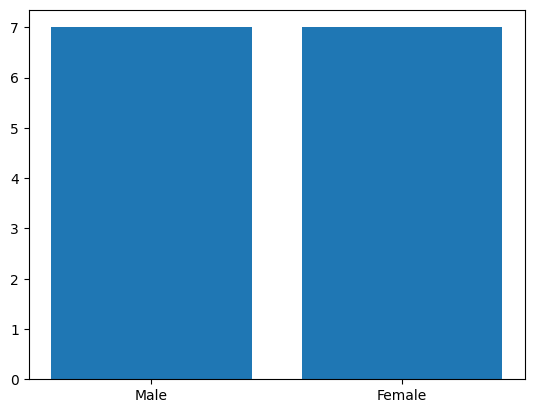

In [757]:
plt.bar(sales['Gender'],sales['Quantity'])
plt.show()

Text(0, 0.5, 'Total')

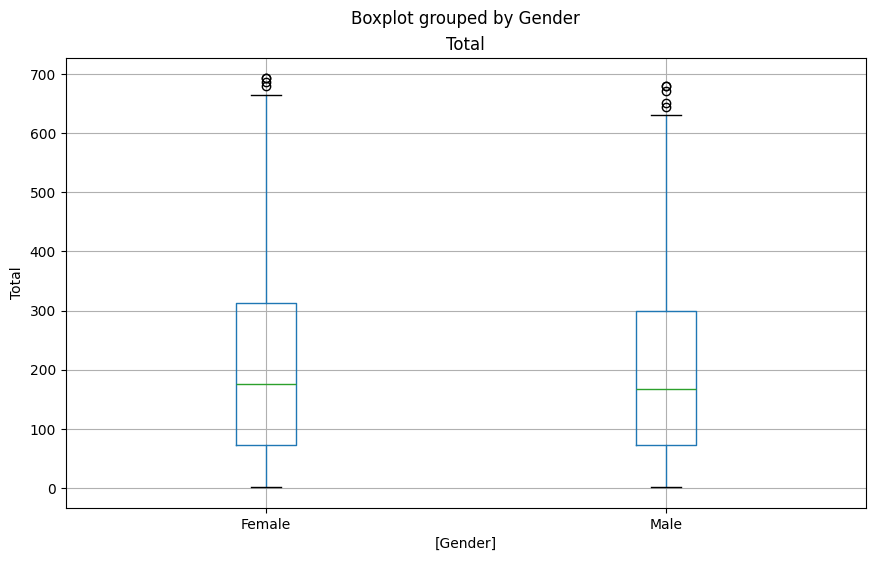

In [758]:
ax = sales[['Total','Gender']].boxplot(by = 'Gender',figsize = (10,6))
ax.set_ylabel('Total')

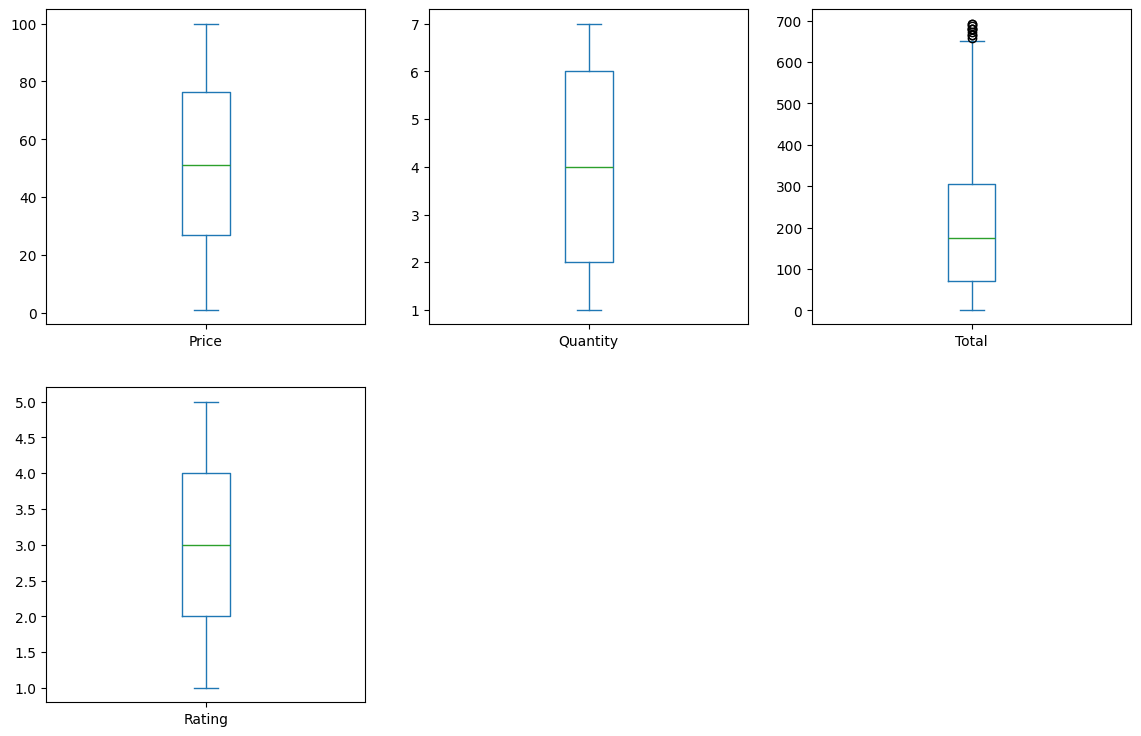

In [759]:
boxplot = ['Date',	'Price',	'Quantity',	'Total',	'Rating']
sales[boxplot].plot(kind = 'box',subplots = True , layout = (2,3),figsize = (14,9))
#plt.boxplot(sales[boxplot])
plt.show()

## column wrangling

In [760]:
sales.columns

Index(['Invoice ID', 'Date', 'Time', 'Gender', 'Location', 'City', 'Member',
       'Category', 'Price', 'Quantity', 'Total', 'Payment', 'Rating'],
      dtype='object')

In [761]:
sales['total_per_rating'] = sales['Total'] / sales['Rating']

In [762]:
sales['total_per_rating'].head()

0     15.000000
1     58.333333
2     22.800000
3    356.000000
4    102.500000
Name: total_per_rating, dtype: float64

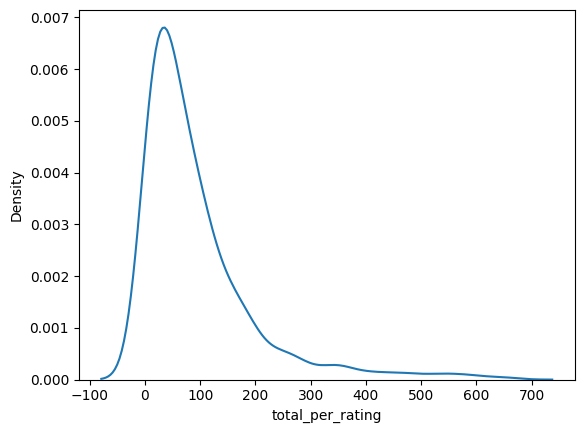

In [763]:
sns.distplot(sales['total_per_rating'],hist = False)
plt.show()

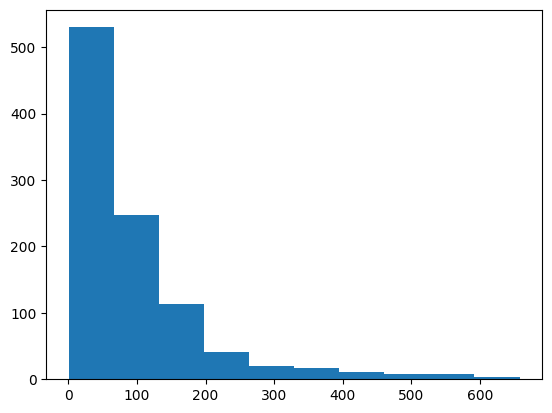

In [764]:
plt.hist(sales['total_per_rating'])
plt.show()

In [765]:
sales['Calcuated_cost'] = sales['Quantity'] * sales['Price']

In [766]:
(sales['Calcuated_cost'] != sales['Price']).sum()

np.int64(860)

In [767]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Invoice ID        1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Time              1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Location          1000 non-null   object        
 5   City              1000 non-null   object        
 6   Member            1000 non-null   object        
 7   Category          1000 non-null   object        
 8   Price             1000 non-null   int64         
 9   Quantity          1000 non-null   int64         
 10  Total             1000 non-null   int64         
 11  Payment           1000 non-null   object        
 12  Rating            1000 non-null   int64         
 13  total_per_rating  1000 non-null   float64       
 14  Calcuated_cost    1000 no

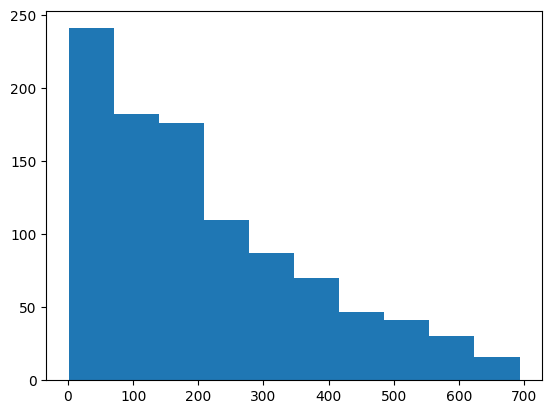

In [768]:
plt.hist(sales['Total'])
plt.show()

In [769]:
sales['Total'].head()

0     30
1    175
2    114
3    356
4    410
Name: Total, dtype: int64

In [770]:
sales['Total'] += 1.03

In [771]:
sales['Total'].head()

0     31.03
1    176.03
2    115.03
3    357.03
4    411.03
Name: Total, dtype: float64

## Selection & Indexing 

In [772]:
sales.loc[sales['City'] =='NewYork']

,Invoice ID,Date,Time,Gender,Location,City,Member,Category,Price,Quantity,Total,Payment,Rating,total_per_rating,Calcuated_cost
0,460489604,2018-01-25,16:46,Male,Brookfield,NewYork,Yes,Groceries,30,1,31.03,Cash,2,15.000000,30
5,263634050,2018-03-09,17:55,Male,Brookfield,NewYork,Yes,Clothing,52,4,209.03,Gpay,3,69.333333,208
10,388412668,2018-02-26,11:32,Female,Brookfield,NewYork,No,Furniture,35,4,141.03,Gpay,4,35.000000,140
14,547572603,2018-03-21,13:23,Female,Brookfield,NewYork,No,Fashion,98,7,687.03,Gpay,3,228.666667,686
15,355981315,2018-02-15,15:47,Female,Brookfield,NewYork,Yes,Clothing,78,5,391.03,Card,5,78.000000,390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,699906043,2018-02-15,12:58,Male,Brookfield,NewYork,Yes,Furniture,96,7,673.03,Card,3,224.000000,672
992,927909627,2018-03-02,13:35,Male,Brookfield,NewYork,No,Books,54,1,55.03,Card,1,54.000000,54
993,455112063,2018-03-19,17:30,Female,Brookfield,NewYork,Yes,Clothing,3,3,10.03,Cash,2,4.500000,9
997,82324424,2018-02-06,11:44,Male,Brookfield,NewYork,No,Clothing,71,5,356.03,Card,3,118.333333,355


# Get the mean Total of the Card sales group

In [773]:
sales.loc[sales['Payment'] == 'Card','Total'].mean()

np.float64(207.66665594855306)

# How many records belong to Card or Cash

In [774]:
sales.loc[(sales['Payment'] == 'Cash')| (sales['Payment'] == 'Card')].shape[0]

655

## Get the mean revenue of the sales group Card in NewYork

In [775]:
sales.loc[(sales['Payment'] == 'Card') & (sales['City'] == 'NewYork'),'Total'].mean()

np.float64(224.1069230769231)

## Increase the revenue by 10% to every sale made in NewYour

Inrease the 

In [776]:
sales.loc[sales['City'] == 'NewYork','Total'].head()

0      31.03
5     209.03
10    141.03
14    687.03
15    391.03
Name: Total, dtype: float64

In [777]:
sales.loc[sales['City'] == 'NewYork','Total'] += 1.1

In [778]:
sales.loc[sales['City'] == 'NewYork','Total'].head()

0      32.13
5     210.13
10    142.13
14    688.13
15    392.13
Name: Total, dtype: float64

# befor modeling we must change a few data 

In [779]:
# look that not the best transforming data, but if you add another code, then it will be great :) 
sales['City_id'] = pd.factorize(sales['City'])[0]+1
sales['Location_id'] = pd.factorize(sales['Location'])[0]+1
sales['Price_id'] = pd.factorize(sales['Price'])[0]+1
sales['Payment_id'] = pd.factorize(sales['Payment'])[0]+1
sales['Gender'] = sales['Gender'].map({'Male':0,'Female':1})



In [780]:
sales.describe()


,Invoice ID,Date,Gender,Price,Quantity,Total,Rating,total_per_rating,Calcuated_cost,City_id,Location_id,Price_id,Payment_id
count,1.000000e+03,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.944931e+08,2018-02-14 00:05:45.600000,0.501000,51.112000,4.059000,209.192000,2.972000,93.802367,207.788000,1.992000,1.992000,48.989000,2.001000
min,6.614050e+05,2018-01-01 00:00:00,0.000000,1.000000,1.000000,2.030000,1.000000,0.400000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.508726e+08,2018-01-24 00:00:00,0.000000,27.000000,2.000000,74.105000,2.000000,26.000000,72.000000,1.000000,1.000000,25.000000,1.000000
50%,4.781491e+08,2018-02-13 00:00:00,1.000000,51.000000,4.000000,175.030000,3.000000,60.000000,174.000000,2.000000,2.000000,49.000000,2.000000
75%,7.459453e+08,2018-03-08 00:00:00,1.000000,76.250000,6.000000,306.355000,4.000000,118.500000,304.500000,3.000000,3.000000,73.000000,3.000000
max,9.996658e+08,2018-03-30 00:00:00,1.000000,100.000000,7.000000,694.030000,5.000000,658.000000,693.000000,3.000000,3.000000,100.000000,3.000000
std,2.870685e+08,NaN,0.500249,28.912443,2.027716,165.636913,1.428025,105.246420,165.626167,0.820127,0.820127,27.921721,0.830475


## Machine Learning 

In [781]:
from sklearn.preprocessing import LabelBinarizer , StandardScaler # that for transform yes and no to 1 , 0
from sklearn.linear_model import LogisticRegressionCV, Lasso ,LogisticRegression# classifiction models
from sklearn.ensemble import RandomForestClassifier  # tree model 
from sklearn.model_selection import train_test_split , RandomizedSearchCV , GridSearchCV
from xgboost import XGBClassifier # that also tree model 

# choose the columns

In [782]:
sales.columns

Index(['Invoice ID', 'Date', 'Time', 'Gender', 'Location', 'City', 'Member',
       'Category', 'Price', 'Quantity', 'Total', 'Payment', 'Rating',
       'total_per_rating', 'Calcuated_cost', 'City_id', 'Location_id',
       'Price_id', 'Payment_id'],
      dtype='object')

In [783]:
lb = LabelBinarizer()
featured_columns  = sales[['Gender',	'Rating','total_per_rating', 'Calcuated_cost','City_id', 'Location_id',
       'Price_id', 'Payment_id']]
x = pd.get_dummies(featured_columns, drop_first = True)
y =lb.fit_transform(sales['Member']).ravel()

## split data into training and test datasets

In [784]:
X_train , X_test , y_train , y_test = train_test_split(x , y , random_state = 42 , test_size = 0.4)

## logisticRegressionCV 

In [785]:

Model_linear = LogisticRegressionCV(Cs = [0.01 , 0.1 , 1 , 10] , cv  = 5  , penalty = 'l2',solver = 'liblinear')
#gird1 = GridSearchCV(Model_linear , param_grid , cv = 5 , scoring = 'f1')
Model_linear.fit(X_train , y_train)
Model_linear.score(X_test , y_test)



0.5

## LogisticRegression model

In [786]:
param = {
    'C':[0.01 , 0.1 , 1 , 10],
    'penalty':['l1','l2'],
    'solver':['liblinear']
}
search  = RandomizedSearchCV(
    LogisticRegression(),
    param,
    cv = 5,
    n_iter = 5
)
search.fit(X_train , y_train)
search.score(X_test , y_test)

0.5

## RandomClassifier model

In [787]:
classifer = RandomForestClassifier(n_estimators = 200 , random_state = 42)
classifer.fit(X_train  , y_train)
classifer.score(X_test  , y_test)

0.5025

## Xgboost import XGBClassifier 
## Look, I  try more laborious, maybe it will help 

In [788]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(n_estimators = 100,learing_rate = 0.1)
model_xgb.fit(X_train , y_train)
model_xgb.score(X_test,y_test)

0.495

# Mehhhhhhhhh